In [35]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [36]:
words = open('names.txt','r').read().splitlines()

In [37]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [38]:
block_size = 8

def build_dataset(words):
    block_size = 8
    X,Y = [],[]
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1::]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

In [39]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182579, 8]) torch.Size([182579])
torch.Size([22695, 8]) torch.Size([22695])
torch.Size([22866, 8]) torch.Size([22866])


In [40]:
for x,y in zip(Xtr[:20],Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->' , itos[y.item()])

........ --> g
.......g --> e
......ge --> d
.....ged --> d
....gedd --> y
...geddy --> .
........ --> c
.......c --> a
......ca --> l
.....cal --> v
....calv --> a
...calva --> r
..calvar --> y
.calvary --> .
........ --> m
.......m --> a
......ma --> r
.....mar --> s
....mars --> h
...marsh --> a


In [41]:
class Linear:

    def __init__(self,fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in,fan_out)) / fan_in**0.5 #kaiming init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

#----------------------------------------------------------------------------------------------------------

class BatchNorm1d:

    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #parameters trained by backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers updated on a momentum rolling basis
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim,keepdim=True)
            xvar = x.var(dim,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean)/ torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

#----------------------------------------------------------------------------------------------------------

class Tanh():
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

#-----------------------------------------------------------------------------------------------------------

class Embedding:
    def __init__(self,num_embeddings,embedding_dims):
        self.weights = torch.randn((num_embeddings,embedding_dims))

    def __call__(self,IX):
        self.out = self.weights[IX]
        return self.out

    def parameters(self):
        return [self.weights]

#-----------------------------------------------------------------------------------------------------------

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, d):
        B,T,C = d.shape
        d = d.view(B,T//self.n,C*self.n)
        if(d.shape[1]==1):
            d = d.squeeze(1)
        self.out = d
        return self.out

    def parameters(self):
        return []

#-----------------------------------------------------------------------------------------------------------

class Sequential:
     def __init__(self, layers):
         self.layers = layers

     def __call__(self, x):
         for layer in self.layers:
             x = layer(x)
         self.out = x
         return self.out

     def parameters(self):
         return [p for layer in self.layers for p in layer.parameters()]


In [42]:
torch.manual_seed(42)

In [43]:
n_embd = 27
n_hidden = 128

model = Sequential([
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight*=0.1

parameters = model.parameters()

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

77428

In [44]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb = Xtr[ix],Ytr[ix]

    #forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits,Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i<150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000 == 0:
        print(f'{i}/{max_steps} === {loss.item():.4f}')
    lossi.append(loss.log10().item())
print(f'{i+1}/{max_steps} === {loss.item():.4f}')

0/200000 === 3.3235
10000/200000 === 1.6383
20000/200000 === 2.2347
30000/200000 === 2.1187
40000/200000 === 1.8783
50000/200000 === 2.1054
60000/200000 === 1.9877
70000/200000 === 2.0084
80000/200000 === 1.9725
90000/200000 === 1.3485
100000/200000 === 1.7707
110000/200000 === 2.2395
120000/200000 === 2.1221
130000/200000 === 2.2282
140000/200000 === 1.7261
150000/200000 === 1.2063
160000/200000 === 2.1462
170000/200000 === 2.2292
180000/200000 === 1.5357
190000/200000 === 1.4677
200000/200000 === 2.0669


In [45]:
for layer in model.layers:
    print(layer.__class__.__name__,":",tuple(layer.out.shape) )

Embedding : (32, 8, 27)
FlattenConsecutive : (32, 4, 54)
Linear : (32, 4, 128)
BatchNorm1d : (32, 4, 128)
Tanh : (32, 4, 128)
FlattenConsecutive : (32, 2, 256)
Linear : (32, 2, 128)
BatchNorm1d : (32, 2, 128)
Tanh : (32, 2, 128)
FlattenConsecutive : (32, 256)
Linear : (32, 128)
BatchNorm1d : (32, 128)
Tanh : (32, 128)
Linear : (32, 27)


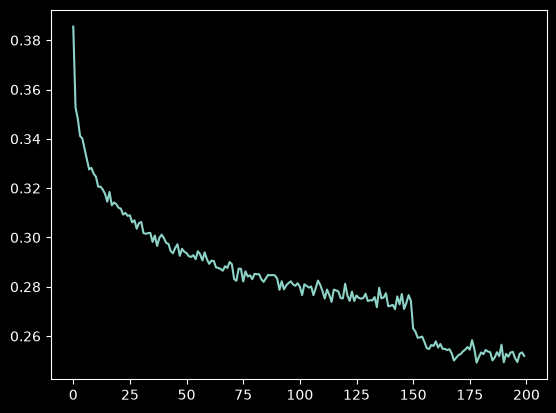

In [46]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [47]:
for layer in model.layers:
    layer.training = False

In [48]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 1.764333724975586
val 1.9869304895401


In [51]:
split_loss('test')

test 1.984153389930725


In [49]:
for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1).item()

        context=context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

hatteico.
zeyna.
franky.
kaseira.
mavi.
dezlynn.
aazaiah.
francesco.
adalynn.
reon.
dep.
shad.
lohfes.
layce.
renley.
marelyn.
anhar.
ahlas.
kayleenice.
kerel.


In [50]:
#Base Code
#train 2.058713912963867
#val 2.1070566177368164

#More Custom Layering
#train 2.058713912963867
#val 2.1070566177368164

#Block Size = 8
#train 1.921554684638977
#val 2.025789260864258

#3 layers Wavenet Implementation , with 170897 params
#train 1.778878092765808
#val 1.9803876876831055

#Making hidden layers 68 from 200
#train 1.9377679824829102
#val 2.0254154205322266